# CKG Reasoner v2 — D7 Dengue (n=989) Frozen External Validation

**Purpose:** additional frozen-CKG validation using the existing CKG Reasoner v2 Dengue knowledge representation.

**Protocol:** outcome labels are retained only for retrospective external evaluation. They are not used to construct the CKG representation, fit K-means, estimate centroids, tune the reasoner, or select K. The primary clustering representation is the full four-dimensional post-KG vector `variables=None` = `[P_evidence, r, c, Confidence_Score]`.

**Important:** inspect the `hmap_report()` before interpreting results. Dataset-specific variables that cannot be mapped to an existing Dengue EFN are intentionally left unused rather than changing the frozen knowledge representation.

## 0. Reproducibility configuration

In [7]:
# Frozen-validation configuration
DISEASE = "Dengue"
TARGET = "dengue_label"
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

# K is deliberately NOT chosen from outcome performance.
# It will be selected below from the internal label-free K-means diagnostics.
BASELINE_K = None

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline clustering variables:", CLUSTER_VARIABLES)
print("K selection: label-free internal diagnostic only")

Disease: Dengue
Target: dengue_label
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']
K selection: label-free internal diagnostic only


## 1. Colab / package setup

In [8]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER — COLAB SOURCE SETUP + VALIDATION
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")
DATA_PATH = os.path.join(CKG_PATH, "data")

print("=" * 70)
print("CKG REASONER — COLAB SOURCE SETUP")
print("=" * 70)

print("PACKAGE_PATH :", PACKAGE_PATH)
print("SRC_PATH     :", SRC_PATH)
print("CKG_PATH     :", CKG_PATH)

# ------------------------------------------------------------
# 1. Validate package structure
# ------------------------------------------------------------

required_directories = {
    "Package directory": PACKAGE_PATH,
    "Source directory": SRC_PATH,
    "CKG package directory": CKG_PATH,
}

for label, path in required_directories.items():
    exists = os.path.isdir(path)
    print(f"{label:<24}: {'OK' if exists else 'MISSING'}")

    if not exists:
        raise FileNotFoundError(
            f"{label} not found:\n{path}"
        )


required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing:\n"
        + "\n".join(f"  - {name}" for name in missing_files)
    )

print("\nRequired core package files: OK")


# ------------------------------------------------------------
# 2. Remove previously added CKG package paths
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving previous CKG source paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Force the selected source directory to highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive source path:")
print(" ", sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in sorted(removed_modules):
        print("  ", name)
else:
    print("\nNo cached CKG modules found.")

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Display package contents before import
# ------------------------------------------------------------

print("\n=== PACKAGE CONTENTS ===")

package_files = sorted(os.listdir(CKG_PATH))

for filename in package_files[:30]:
    print("  ", filename)

if len(package_files) > 30:
    print(f"  ... and {len(package_files) - 30} more")


# ------------------------------------------------------------
# 6. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 7. Verify imported package
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(" ", ckg_reasoner.__file__)

print("\nPackage path:")
for p in ckg_reasoner.__path__:
    print(" ", p)

CKG_VERSION = getattr(
    ckg_reasoner,
    "__version__",
    "NO VERSION"
)

print("\nVersion:", CKG_VERSION)
print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)
print("CKGModel:", CKGModel)


# ------------------------------------------------------------
# 8. Safety check:
#    ensure Colab did not import another installed CKG package
# ------------------------------------------------------------

imported_file = os.path.realpath(ckg_reasoner.__file__)
expected_root = os.path.realpath(SRC_PATH)

try:
    common_root = os.path.commonpath(
        [imported_file, expected_root]
    )
except ValueError:
    common_root = ""

if common_root != expected_root:
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 9. Check important modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

missing_modules = []

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)
    exists = os.path.isfile(path)

    print(
        f"{filename:<30}"
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        missing_modules.append(filename)


# ------------------------------------------------------------
# 10. Check bundled knowledge/data files
# ------------------------------------------------------------

print("\n=== DATA / KNOWLEDGE CHECK ===")
print("Data directory:", DATA_PATH)
print(
    "Data directory exists:",
    os.path.isdir(DATA_PATH)
)

yaml_files = []

if os.path.isdir(DATA_PATH):

    for root, dirs, files in os.walk(DATA_PATH):

        for filename in files:

            if filename.lower().endswith(
                (".yaml", ".yml")
            ):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    yaml_files = sorted(yaml_files)

    print("YAML/YML files found:", len(yaml_files))

    for path in yaml_files:
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )

else:
    print("WARNING: bundled data directory not found.")


# ------------------------------------------------------------
# 11. Final diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CKG REASONER SETUP COMPLETED")
print("=" * 70)

print("Source       :", SRC_PATH)
print("Imported from:", ckg_reasoner.__file__)
print("Version      :", CKG_VERSION)
print("CKGModel     : READY")

print(
    "Core files   :",
    "OK" if not missing_files else "MISSING"
)

print(
    "Extra modules:",
    "OK" if not missing_modules
    else f"{len(missing_modules)} MISSING"
)

print(
    "Knowledge YAML:",
    len(yaml_files)
)

print("=" * 70)

CKG REASONER — COLAB SOURCE SETUP
PACKAGE_PATH : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
SRC_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
CKG_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
Package directory       : OK
Source directory        : OK
CKG package directory   : OK

Required core package files: OK

Removing previous CKG source paths:
   /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

Active source path:
  /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

Removed cached CKG modules:
   ckg_reasoner
   ckg_reasoner.clinical_transformer
   ckg_reasoner.condition_logic
   ckg_reasoner.confidence
   ckg_reasoner.config
   ckg_reasoner.evaluation
   ckg_reasoner.explanation
   ckg_reasoner.functions
   ckg_reasoner.gaussian
   ckg_reasoner.graphview
   ckg_reasoner.kmeans
   ckg_reasoner.knowledge
   ckg_reasoner.legacy_activation
   ckg_reasoner.mahalanobis
   ckg_reasoner.mapping
   ckg_reasoner.model
 

In [10]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


In [11]:
import ckg_reasoner
from ckg_reasoner import (
    CKGModel,
    HardAssignment,
    KMeansPartition,
    GaussianPartition,
    MahalanobisPartition
)

print("CKG Reasoner version:", ckg_reasoner.__version__)

model = CKGModel()

print("CKGModel created successfully.")

CKG Reasoner version: 2
CKGModel created successfully.


## 2. Load and minimally harmonize the external cohort

In [12]:
import pandas as pd
import numpy as np

DATA_PATH = r"/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/Dengue_diseases_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Normalize outcome for retrospective evaluation only.
df["dengue_label"] = pd.to_numeric(df["dengue_label"], errors="raise").astype(int)

# Rename only variables with direct, unambiguous correspondence to names already
# used by the frozen Dengue mapping layer. Uncertain fields remain unchanged so
# hmap_report() can expose them rather than silently forcing a mapping.
df = df.rename(columns={
    "age": "Age",
    "gender": "Gender",
    "wbc_count": "WBC Count",
    "platelet_count": "Platelet Count",
})

print("Raw shape:", df_raw.shape)
print("Analysis shape:", df.shape)
print("Target distribution:")
print(df[TARGET].value_counts(dropna=False))
display(df.head())

print("\nColumns supplied to hmap:")
for col in df.columns:
    print(col)

Raw shape: (989, 9)
Analysis shape: (989, 9)
Target distribution:
dengue_label
1    644
0    345
Name: count, dtype: int64


,Age,Gender,hemoglobin_g_dl,WBC Count,differential_count,rbc_count,Platelet Count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1



Columns supplied to hmap:
Age
Gender
hemoglobin_g_dl
WBC Count
differential_count
rbc_count
Platelet Count
platelet_distribution_width
dengue_label


## 3. Audit mapping and run the **frozen** Dengue KG reasoning

In [13]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)
print("\nDetected target:")
print(model.target_column_)
print("\nHeader mapping report — REVIEW THIS BEFORE USING RESULTS:")
report = model.hmap_report()
display(report)

# Frozen-validation guardrail: this notebook does not edit the KB, g/I/S/C,
# Information-Gate parameters, or reasoning equations in response to outcomes.

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']

Detected schema:
None

Detected target:
None

Header mapping report — REVIEW THIS BEFORE USING RESULTS:


,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0000,None,None,not_mapped
1,Age,None,ignored,1.0000,None,None,not_mapped
2,Gender,None,ignored,1.0000,None,None,not_mapped
3,hemoglobin_g_dl,HGB_hemoglobin_g_dl,alias_exact,1.0000,None,g/dL,unresolved
4,WBC Count,LEU_wbc,alias_exact,1.0000,None,/uL,unresolved
5,differential_count,None,unmatched,0.5625,None,None,not_mapped
6,rbc_count,None,unmatched,0.8750,None,None,not_mapped
7,Platelet Count,MTP_platelet_count,alias_exact,1.0000,None,/uL,unresolved
8,platelet_distribution_width,PDW_pdw,alias_exact,1.0000,None,%,unresolved
9,dengue_label,None,ignored,1.0000,None,None,not_mapped


In [14]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=989)

## 4. Single-record reasoning sanity check

In [15]:
model.evidence("Dengue", row=0)
model.Continuous_reasoning("Dengue", row=0)
model.Deterministic_reasoning("Dengue", row=0)
model.Uncertainty("Dengue", row=0)
model.explain("Dengue", row=0)

{'Dengue Fever': {'patient_id': 0,
  'disease': 'Dengue Fever',
  'evidence_facts': [{'feature': 'LEU_laboratory',
    'name': 'Leukopenia',
    'observed': True,
    'observations': [{'component': 'wbc', 'value': 2200.0}],
    'similarity': 0.998152780580984,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.6723589708368304,
    'negative_contribution': 0.0033024992395061454},
   {'feature': 'MTP_laboratory',
    'name': 'Mild Thrombocytopenia',
    'observed': True,
    'observations': [{'component': 'platelet_count', 'value': 62000.0}],
    'similarity': 0.9985848548550337,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.6723915459323819,
    'negative_contribution': 0.0032883192982020985},
   {'feature': 'HGB_laboratory',
    'name': 'Hemoglobin',
    'observed': True,
    'observations': [{'component': 'hemoglobi

## 5. Label-free 4-D clustering diagnostics and K selection

Elbow-recommended cluster number: 3
Silhouette-recommended cluster number: 4
Combined best cluster number: 3


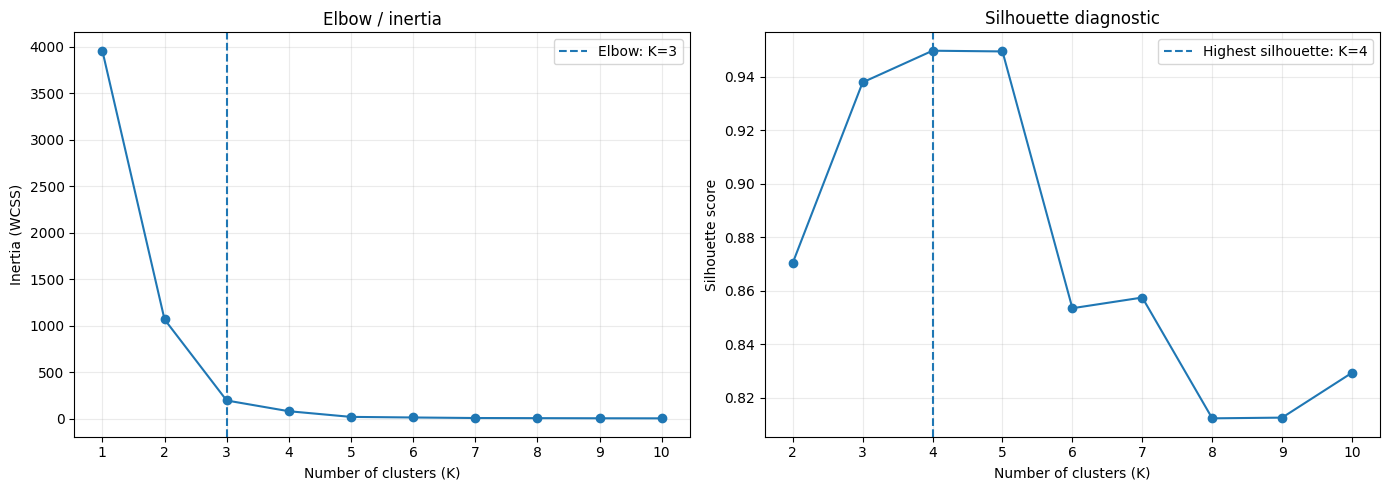

kmeans diagnostics complete. Advisory recommended n=3; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,3956.000000,NaN,0.000000,NaN,NaN
1,2,2,1067.228472,0.870440,0.849787,0.422704,0.636245
2,3,3,195.010789,0.937983,1.000000,0.913916,0.956958
3,4,4,79.619748,0.949819,0.887658,1.000000,0.943829
4,5,5,18.568583,0.949551,0.756464,0.998051,0.877258
5,6,6,12.249111,0.853506,0.606284,0.299554,0.452919
6,7,7,6.465163,0.857501,0.455917,0.328603,0.392260
7,8,8,5.054285,0.812317,0.304034,0.000000,0.152017
8,9,9,3.752433,0.812585,0.152112,0.001951,0.077032
9,10,10,3.000281,0.829376,0.000000,0.124067,0.062034


Elbow k: 3
Silhouette k: 4
Combined internal best k: 3
SELECTED external-validation K (label-free): 3


In [16]:
# Diagnostics use ONLY the four post-KG coordinates; outcome labels are not passed here.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)

elbow_k = kdiag.attrs.get("elbow_recommended_n")
silhouette_k = kdiag.attrs.get("silhouette_recommended_n")
combined_k = kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n"))

# Prespecified external-validation rule: use the combined INTERNAL diagnostic
# recommendation when available; otherwise fall back to silhouette.
BASELINE_K = int(combined_k if combined_k is not None else silhouette_k)

print("Elbow k:", elbow_k)
print("Silhouette k:", silhouette_k)
print("Combined internal best k:", combined_k)
print("SELECTED external-validation K (label-free):", BASELINE_K)

## 6. Label-free selected 4-D partition and retrospective external evaluation

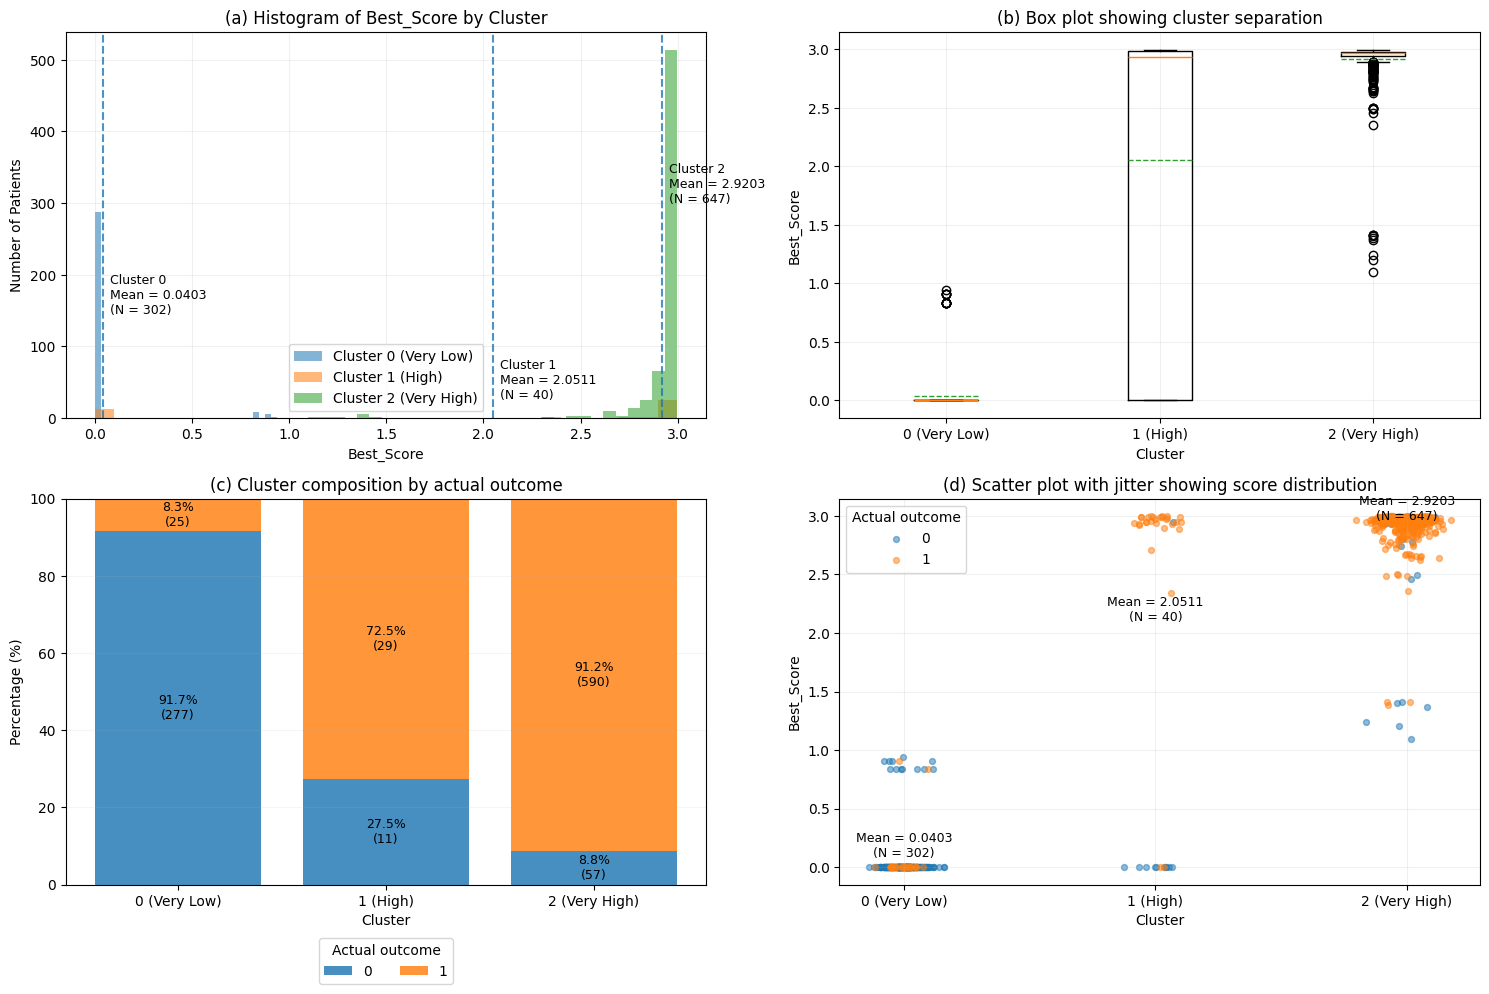

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


ALL-RECORD EVALUATION
{'n': 989, 'accuracy': 0.8766430738119313, 'balanced_accuracy': np.float64(0.8595238095238096), 'precision_macro': 0.6097065416542985, 'recall_macro': 0.5730158730158731, 'f1_macro': 0.5900932664652964, 'f1_weighted': 0.8938711349648081, 'mcc': np.float64(0.7391463915749515), 'cohen_kappa': np.float64(0.7361299733413813), 'ground_truth_counts': {'positive': 644, 'negative': 345}, 'prediction_counts': {'positive': 647, 'negative': 302, 'indeterminate': 40}, 'labels': ['indeterminate', 'negative', 'positive'], 'confusion_matrix': array([[  0,   0,   0],
       [ 11, 277,  57],
       [ 29,  25, 590]]), 'f1_positive': 0.9140201394268009, 'f1': 0.9140201394268009, 'n_total': 989, 'n_indeterminate': 40, 'coverage': 0.9595551061678463, 'abstention_rate': 0.04044489383215369, 'positive_disease': 'Dengue Fever', 'tag_method': 'kmeans', 'evaluation_mode': 'all records; indeterminate retained as a third predicted label'}

DECIDED/SUBSET EVALUATION
{'n': 949, 'accuracy': 0.9

In [17]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.876643,0.859524,0.739146,0.914020,0.935024,0.959555,40
1,No P_evidence,"r, c, Confidence_Score",1.000000,0.876643,0.859524,0.739146,0.914020,0.935024,0.959555,40
2,No r,"P_evidence, c, Confidence_Score",0.946258,0.866532,0.843685,0.715990,0.907280,0.927900,0.959555,40
3,No c,"P_evidence, r, Confidence_Score",0.992232,0.878665,0.862422,0.743711,0.915438,0.936508,0.959555,40
4,P_evidence only,P_evidence,0.870293,0.898888,0.875259,0.780771,0.937405,0.940996,0.976744,23
5,"Profile only (r,c)","r, c",0.888008,0.900910,0.876812,0.783715,0.936882,0.939024,0.981800,18
6,No CS [exploratory],"P_evidence, r, c",0.870293,0.898888,0.875259,0.780771,0.937405,0.940996,0.976744,23


## 8. K sensitivity and 20-seed stability

In [19]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.914055,0.894979,0.935557,1.000000
1,3,0.876643,0.859524,0.935024,0.959555
2,4,0.037412,0.035455,0.947368,0.040445
3,5,0.861476,0.839803,0.940705,0.936299
4,6,0.809909,0.800207,0.939527,0.879676
5,7,0.809909,0.800207,0.939527,0.879676
6,8,0.778564,0.776139,0.936052,0.848332
7,9,0.521739,0.407350,0.954717,0.570273
8,10,0.770475,0.769928,0.935089,0.840243


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.935024,0.959555
1,1,1.0,0.935024,0.959555
2,2,1.0,0.935024,0.959555
3,3,1.0,0.935024,0.959555
4,4,1.0,0.935024,0.959555
5,5,1.0,0.935024,0.959555
6,6,1.0,0.935024,0.959555
7,7,1.0,0.935024,0.959555
8,8,1.0,0.935024,0.959555
9,9,1.0,0.935024,0.959555


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [20]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.868554,0.887765,0.906977
coverage,0.946411,0.959555,0.971689
balanced_accuracy_all,0.852839,0.875730,0.897390
mcc_all,0.710080,0.752809,0.794784
f1_positive_decided,0.921309,0.934979,0.948779


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [21]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,1.0,0.876643,0.935024,0.959555
1,importance_unity,1.0,0.876643,0.935024,0.959555


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [22]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


...

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.0,0.935024,0.959555
1,alpha=0.025,0.025,10,0.85,1.0,0.935024,0.959555
2,alpha=0.1,0.100,10,0.85,1.0,0.935024,0.959555
3,beta=5,0.050,5,0.85,1.0,0.935024,0.959555
4,beta=20,0.050,20,0.85,1.0,0.935024,0.959555
5,gamma=0.75,0.050,10,0.75,1.0,0.935024,0.959555
6,gamma=0.95,0.050,10,0.95,1.0,0.935024,0.959555


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [23]:
PROTECTED_COLUMNS={TARGET,"id","ID","Id","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_581/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 43.  45.  50.  57.  51.  61.   6.  21.  29.  31.  37.  39.  44.  45.
  56.  58.  nan  nan  30.  40.  50.  54.  55.  59.  39.  40.  47.  49.
   5.   3.   7.   6.  25.  24.  35.  36.  39.  15.  17.  18.  19.  22.
  27.  31.  37.  47.  21.  32.  41.  26.  19.   7.   9.  14.  17.  19.
  22.  28.  23.  29.  31.  39.  26.  27.  16.  19.  25.  26.   4.   5.
   7.  nan   5.  16.  19.  49.  69.  nan  28.  29.  nan  35.  36.  37.
  49.  39.  67.  60.  58.  48.  21.  27.  79.  55.  61.  64.  63.  58.
  53.  54.  48.  47.  43.  29.  30.  31.   4.   8.  nan  15.  nan  nan
   7.   9.   4.   5.  17.  19.  20.  21.  23.  25.  33.  39.  40.  42.
  51.  62.  61.  35.  29.  41.  59.  nan  23.  45.  34.  45.  34.  33.
  98.  67.  47.  21.  98.  19.  42.  nan  76.  67.  66.  76.  94.  56.
  58.  39.  49.  58.  55.  20.   5.  nan  25.  34.  30.  27.  87.

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=6; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_581/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 43.  nan  50.  nan  nan  61.  nan  nan  nan  nan  37.  39.  44.  45.
  nan  58.  57.  29.  30.  nan  50.  54.  55.  59.  39.  40.  47.  nan
   5.   3.   7.   6.  25.  24.  35.  36.  39.  nan  17.  nan  19.  22.
  27.  31.  37.  47.  21.  32.  nan  26.  nan   7.   9.  14.  nan  nan
  22.  28.  nan  29.  31.  39.  26.  27.  16.  19.  25.  26.   4.  nan
  nan  nan   5.  16.  19.  49.  69.  70.  nan  29.  31.  35.  nan  37.
  49.  39.  67.  nan  58.  48.  21.  27.  79.  55.  61.  64.  nan  nan
  53.  54.  48.  nan  43.  nan  30.  31.   4.  nan   3.  nan  18.  nan
   7.   9.   4.   5.  17.  19.  20.  21.  nan  25.  nan  39.  40.  nan
  51.  nan  61.  3

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=7; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_581/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 43.  45.  nan  nan  51.  61.   6.  21.  29.  nan  nan  39.  nan  45.
  nan  nan  57.  nan  30.  nan  nan  54.  nan  nan  39.  40.  nan  49.
   5.  nan   7.  nan  nan  nan  35.  36.  nan  nan  nan  18.  nan  22.
  nan  31.  nan  nan  nan  32.  41.  nan  19.  nan   9.  14.  nan  nan
  nan  nan  23.  29.  31.  nan  nan  nan  nan  19.  25.  26.  nan   5.
  nan   8.   5.  16.  19.  nan  nan  70.  nan  29.  31.  35.  nan  37.
  nan  nan  67.  nan  58.  nan  21.  27.  79.  55.  nan  nan  nan  nan
  nan  nan  nan  nan  43.  29.  30.  31.   4.  nan  nan  15.  18.  nan
   7.  nan  nan   5.  nan  nan  20.  nan  23.  nan  nan  39.  nan  nan
  51.  62.  61.  n

Successful matches found: 4 dataset headings mapped to ontology headings.
            dataset_heading    ontology_heading
            hemoglobin_g_dl HGB_hemoglobin_g_dl
                  WBC Count             LEU_wbc
             Platelet Count  MTP_platelet_count
platelet_distribution_width             PDW_pdw
Ignored metadata/target headings: ['id', 'Age', 'Gender', 'dengue_label']
Unmatched/skipped headings: ['differential_count', 'rbc_count']
Graph fitting completed for 989 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=9; target ordering=Dengue Fever).


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,779,0.711037,0.773509,0.782350,0.609068,0.930902,0.846309
1,0.25,1995,0.803516,0.857432,0.837371,0.705378,0.932692,0.942366
2,0.50,3933,0.520015,0.687563,0.667236,0.508999,0.939424,0.749242


## 13. Export manuscript experiment tables

In [24]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/"E_Dengue_D7_989"
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
kdiag.to_csv(OUT/"kmeans_internal_diagnostics.csv",index=False)
with open(OUT/"selected_k.txt","w") as f:
    f.write(f"label_free_selected_k={BASELINE_K}\n")
    f.write(f"elbow_k={elbow_k}\n")
    f.write(f"silhouette_k={silhouette_k}\n")
    f.write(f"combined_k={combined_k}\n")
print("Saved external-validation experiment tables to:",OUT)

Saved external-validation experiment tables to: /content/drive/MyDrive/CKG/Results/E_Dengue_D7_989


## 14. Original explainability / FOL / output cells (preserved)

In [25]:
# Optional: full-cohort FOL/report generation can be expensive and very verbose.
# Uncomment only when you specifically need record-level reports for every patient.
# for idx in range(len(model.df_)):
#     model.explain("Dengue", row=idx, format="fol")
#     model.explainable_layer("Dengue", row=idx, format="report")
print("Full-cohort FOL export skipped by default; single-record explainability remains available below.")

Full-cohort FOL export skipped by default; single-record explainability remains available below.


In [26]:
result_all = model.evaluate(
    y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km
)
result_all

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


{'n': 989,
 'accuracy': 0.8766430738119313,
 'balanced_accuracy': np.float64(0.8595238095238096),
 'precision_macro': 0.6097065416542985,
 'recall_macro': 0.5730158730158731,
 'f1_macro': 0.5900932664652964,
 'f1_weighted': 0.8938711349648081,
 'mcc': np.float64(0.7391463915749515),
 'cohen_kappa': np.float64(0.7361299733413813),
 'ground_truth_counts': {'positive': 644, 'negative': 345},
 'prediction_counts': {'positive': 647, 'negative': 302, 'indeterminate': 40},
 'labels': ['indeterminate', 'negative', 'positive'],
 'confusion_matrix': array([[  0,   0,   0],
        [ 11, 277,  57],
        [ 29,  25, 590]]),
 'f1_positive': 0.9140201394268009,
 'f1': 0.9140201394268009,
 'n_total': 989,
 'n_indeterminate': 40,
 'coverage': 0.9595551061678463,
 'abstention_rate': 0.04044489383215369,
 'positive_disease': 'Dengue Fever',
 'tag_method': 'kmeans',
 'evaluation_mode': 'all records; indeterminate retained as a third predicted label'}

In [27]:
result_selective = model.evaluate_tag(
    y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km
)
result_selective

{'n': 949,
 'accuracy': 0.9135932560590094,
 'balanced_accuracy': np.float64(0.8943454554306023),
 'precision_macro': 0.9145598124814478,
 'recall_macro': 0.8943454554306023,
 'f1_macro': 0.9030464770903727,
 'f1_weighted': 0.912514991116529,
 'mcc': np.float64(0.8086526523946399),
 'cohen_kappa': np.float64(0.8063400260808107),
 'ground_truth_counts': {'1': 615, '0': 334},
 'prediction_counts': {'1': 647, '0': 302},
 'labels': ['0', '1'],
 'confusion_matrix': array([[277,  57],
        [ 25, 590]]),
 'binary_label_order': ['0', '1'],
 'tn': 277,
 'fp': 57,
 'fn': 25,
 'tp': 590,
 'sensitivity': np.float64(0.959349593495935),
 'specificity': np.float64(0.8293413173652695),
 'npv': np.float64(0.9172185430463576),
 'ppv': np.float64(0.9119010819165378),
 'f1_positive': 0.9350237717908082,
 'f1': 0.9350237717908082,
 'roc_auc': np.float64(0.9029842753517355),
 'average_precision': np.float64(0.914091653879525),
 'log_loss': 1.1358185148127395,
 'n_total': 989,
 'n_indeterminate': 40,
 'co

In [28]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_D7_Dengue_989_FrozenValidation.xlsx"
model.output(output_path, positive_disease=DISEASE, method=km)
print("Saved:", output_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.0 MB/s eta 0:00:00
Output written: /content/drive/MyDrive/CKG/Results/CKG_D7_Dengue_989_FrozenValidation.xlsx (method=kmeans); mismatch rows are yellow when actual outcome is available.
Saved: /content/drive/MyDrive/CKG/Results/CKG_D7_Dengue_989_FrozenValidation.xlsx


In [29]:
print("\n" + "=" * 70)
print("ALL-RECORD RETROSPECTIVE EXTERNAL EVALUATION")
print("=" * 70)
for metric, value in result_all.items(): print(f"{metric}: {value}")
print("\n" + "=" * 70)
print("DECIDED/SUBSET RETROSPECTIVE EXTERNAL EVALUATION")
print("=" * 70)
for metric, value in result_selective.items(): print(f"{metric}: {value}")
print("\nK was selected without outcome labels:", BASELINE_K)


ALL-RECORD RETROSPECTIVE EXTERNAL EVALUATION
n: 989
accuracy: 0.8766430738119313
balanced_accuracy: 0.8595238095238096
precision_macro: 0.6097065416542985
recall_macro: 0.5730158730158731
f1_macro: 0.5900932664652964
f1_weighted: 0.8938711349648081
mcc: 0.7391463915749515
cohen_kappa: 0.7361299733413813
ground_truth_counts: {'positive': 644, 'negative': 345}
prediction_counts: {'positive': 647, 'negative': 302, 'indeterminate': 40}
labels: ['indeterminate', 'negative', 'positive']
confusion_matrix: [[  0   0   0]
 [ 11 277  57]
 [ 29  25 590]]
f1_positive: 0.9140201394268009
f1: 0.9140201394268009
n_total: 989
n_indeterminate: 40
coverage: 0.9595551061678463
abstention_rate: 0.04044489383215369
positive_disease: Dengue Fever
tag_method: kmeans
evaluation_mode: all records; indeterminate retained as a third predicted label

DECIDED/SUBSET RETROSPECTIVE EXTERNAL EVALUATION
n: 949
accuracy: 0.9135932560590094
balanced_accuracy: 0.8943454554306023
precision_macro: 0.9145598124814478
recal

In [30]:
idx = 0
print("Row:", idx)
print("\n=== SCORE / EVIDENCE ===")
print(model.evidence(DISEASE, row=idx))
print("\n=== FOL ===")
print(model.explain(DISEASE, row=idx, format="fol"))

Row: 0

=== SCORE / EVIDENCE ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                 1.00   
1   MTP_laboratory          Mild Thrombocytopenia                 1.00   
2   HGB_laboratory                     Hemoglobin                 0.25   
3   PDW_laboratory    Platelet Distribution Width                 0.25   
4   NEU_laboratory                    Neutropenia                 0.70   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                 1.00   
63    RFL_severity            Respiratory Failure                 1.00   
64    STP_severity        Severe Thrombocytopenia                 1.00   
65    SLW_severity              Severe Leukopenia                 0.70   
66    EXH_severity  Extremely Elevated Hematocrit                 1.00   

    diagnostic_role  patient_activation  support  contradicti

In [31]:
idx = 0
print("Row:", idx)
print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(DISEASE, row=idx))
print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(DISEASE, row=idx))
print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(DISEASE, row=idx))
print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(DISEASE, row=idx))
print("\n=== FOL ===")
print(model.explain(DISEASE, row=idx, format="fol"))

Row: 0

=== EVIDENCE / DISEASE SCORE / SIMILARITY ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                 1.00   
1   MTP_laboratory          Mild Thrombocytopenia                 1.00   
2   HGB_laboratory                     Hemoglobin                 0.25   
3   PDW_laboratory    Platelet Distribution Width                 0.25   
4   NEU_laboratory                    Neutropenia                 0.70   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                 1.00   
63    RFL_severity            Respiratory Failure                 1.00   
64    STP_severity        Severe Thrombocytopenia                 1.00   
65    SLW_severity              Severe Leukopenia                 0.70   
66    EXH_severity  Extremely Elevated Hematocrit                 1.00   

    diagnostic_role  patient_activation 

In [32]:
scores = model.disease_scores()
print(scores)
row_scores = scores.iloc[0].sort_values(ascending=False)
print(row_scores)

for rank, (disease, score) in enumerate(row_scores.items(), start=1):
    print(f"Rank {rank}: {disease} = {score:.6f}")

        Dengue Fever   Malaria  Influenza
row_id                                   
0           0.997720  0.891786   0.664645
1           0.995301  0.863803   0.657549
2           0.993526  0.954345   0.650959
3           0.990192  0.921569   0.643815
4           0.994608  0.870562   0.655757
...              ...       ...        ...
984         0.000000  0.787440   0.004098
985         0.000000  0.004098   0.004098
986         0.000000  0.775193   0.004098
987         0.000000  0.004098   0.004098
988         0.000000  0.730550   0.004098

[989 rows x 3 columns]
Dengue Fever    0.997720
Malaria         0.891786
Influenza       0.664645
Name: 0, dtype: float64
Rank 1: Dengue Fever = 0.997720
Rank 2: Malaria = 0.891786
Rank 3: Influenza = 0.664645
